# Visualisasi Data

In [43]:
import pandas as pd
import csv
import json
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import plotly as py
import seaborn as sns
import seaborn.objects as so
import bokeh as bk


In [69]:
path = '/content/sample_data/'
fileJson  = 'anscombe.json'
fileCsv = 'Sample-Superstore.csv'

Matplotlib

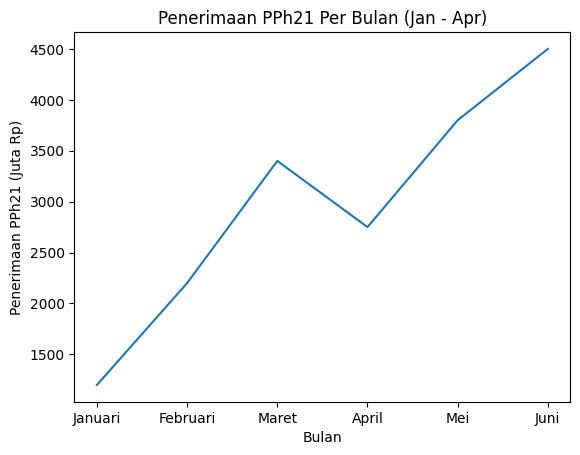

In [62]:
bulan = ['Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni']
pph21 = {'Target':[1500,2000,3500,3000,4000,5000],'penerimaan':[1200,2200,3400,2750,3800,4500]}
plt.plot(bulan, pph21['penerimaan'])
plt.title('Penerimaan PPh21 Per Bulan (Jan - Apr)')
plt.xlabel('Bulan')
plt.ylabel('Penerimaan PPh21 (Juta Rp)')
plt.show()

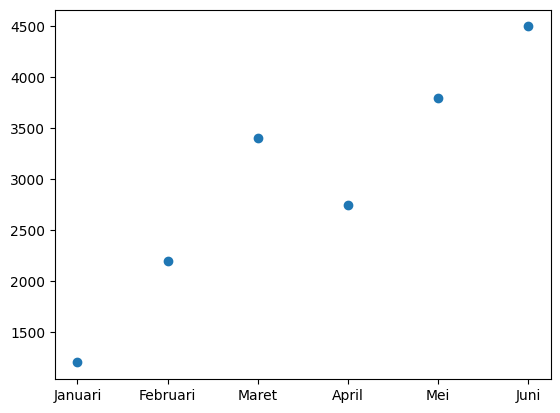

In [64]:
plt.scatter(bulan, pph21['penerimaan'])
plt.title('Penerimaan PPh21 Per Bulan (Jan - Apr)')
plt.xlabel('Bulan')
plt.ylabel('Penerimaan PPh21 (Juta Rp)')
plt.show()

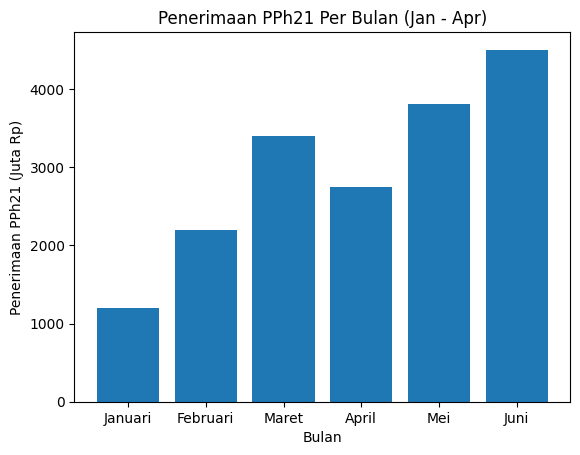

In [68]:
plt.bar(bulan, pph21['penerimaan'])
plt.title('Penerimaan PPh21 Per Bulan (Jan - Apr)')
plt.xlabel('Bulan')
plt.ylabel('Penerimaan PPh21 (Juta Rp)')
plt.show()

In [83]:
df = pd.read_csv(path+fileCsv)
print(f'Banyak Data: {len(df)}')
print('-----------------------------')
print('Sample Data:')
df.head()

Banyak Data: 9426
-----------------------------
Sample Data:


,City,Customer_ID,Customer_Name,Customer_Segment,Order_Date,Order_ID,Order_Priority,Postal_Code,Product_Category,Product_Container,...,Ship_Mode,StateProvince,Discount,Num_of_Records,Product_Base_Margin,Profit,Quantity,Sales,Shipping_Cost,Unit_Price
0,Bowie,2211,Anita Hahn,Home Office,1 Jan 2010,88028,Not Specified,20715,Office Supplies,Large Box,...,Express Air,Maryland,0.08,1,NaN,-425.2084,2,193.88,35.00,95.99
1,New York City,68,Scott Bunn,Corporate,2 Jan 2010,37537,Low,10177,Furniture,Jumbo Drum,...,Delivery Truck,New York,0.00,1,0.56,-308.9280,4,1239.06,48.80,291.73
2,Montebello,1155,Alex Nicholson,Consumer,2 Jan 2010,90853,Critical,90640,Office Supplies,Wrap Bag,...,Regular Air,California,0.08,1,0.39,108.5163,11,157.27,1.97,15.04
3,New York City,68,Scott Bunn,Corporate,2 Jan 2010,37537,Low,10177,Furniture,Jumbo Drum,...,Delivery Truck,New York,0.07,1,0.69,-1679.7600,43,4083.19,45.00,100.98
4,Montebello,1155,Alex Nicholson,Consumer,2 Jan 2010,90853,Critical,90640,Office Supplies,Wrap Bag,...,Express Air,California,0.09,1,0.40,20.2996,4,34.41,2.15,9.11


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9426 entries, 0 to 9425
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   City                  9426 non-null   object 
 1   Customer_ID           9426 non-null   int64  
 2   Customer_Name         9426 non-null   object 
 3   Customer_Segment      9426 non-null   object 
 4   Order_Date            9426 non-null   object 
 5   Order_ID              9426 non-null   int64  
 6   Order_Priority        9426 non-null   object 
 7   Postal_Code           9426 non-null   int64  
 8   Product_Category      9426 non-null   object 
 9   Product_Container     9426 non-null   object 
 10  Product_Name          9426 non-null   object 
 11  Product_Sub-Category  9426 non-null   object 
 12  Region                9426 non-null   object 
 13  Row_ID                9426 non-null   int64  
 14  Ship_Date             9426 non-null   object 
 15  Ship_Mode            

In [151]:
# print(df.filter(['Product_Category','Product_Sub-Category']).unique())
kategori = df.filter(['Product_Sub-Category']).value_counts()
print(sum(kategori))
kategori.to_frame
kategori.info()

9426
<class 'pandas.core.series.Series'>
MultiIndex: 17 entries, ('Paper',) to ('Copiers and Fax',)
Series name: count
Non-Null Count  Dtype
--------------  -----
17 non-null     int64
dtypes: int64(1)
memory usage: 914.0+ bytes


In [134]:
# plt.scatter(kategori.index,kategori.co)
# plt.title('Sales Per Product Category')
# plt.xlabel('Sales')
# plt.ylabel('Product Category')
# plt.show()

Aggregasi dengan Pandas

In [170]:
#GroupBy
print(f"Total:\n{df[['Quantity','Sales']].sum()}")
subCategory_sales=df.groupby('Product_Category')[['Quantity','Sales','Profit']].sum()
subCategory_sales

Total:
Quantity     130064.00
Sales       8951931.32
dtype: float64


,Quantity,Sales,Profit
Product_Category,,,
Furniture,26652,3178623.74,177354.298188
Office Supplies,71542,2258325.55,451990.216492
Technology,31870,3514982.03,683097.884748


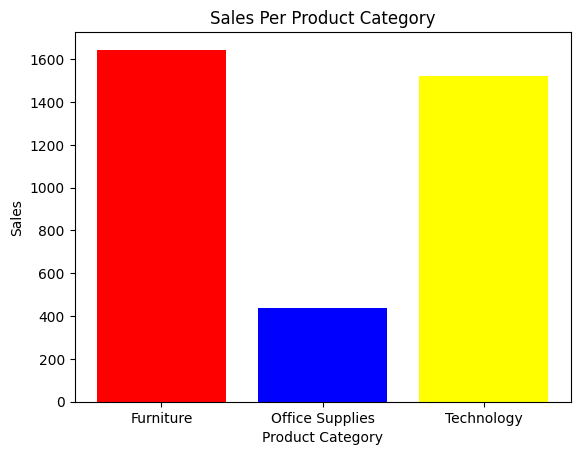

In [148]:
plt.bar(subCategory_sales.index, subCategory_sales['Sales'],color=('red','blue','yellow'))
plt.title('Sales Per Product Category')
plt.xlabel('Product Category')
plt.ylabel('Sales')
plt.show()

In [155]:
sales_profit_byID = df.groupby('Order_ID')[['Sales','Profit']].sum()
sales_profit_byID

,Sales,Profit
Order_ID,,
6,6.93,-4.6400
193,312.30,-37.0400
322,2915.86,-33.8300
358,5230.49,-1078.7900
359,6831.37,-500.3800
...,...,...
91587,592.01,134.9088
91588,48.10,-8.1100
91589,207.11,23.4980


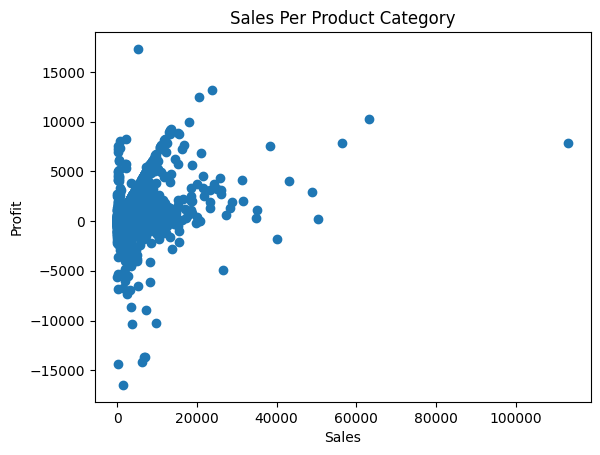

In [156]:
plt.scatter(sales_profit_byID['Sales'], sales_profit_byID['Profit'])
plt.title('Sales Per Product Category')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.show()

                  Quantity       Sales         Profit
Product_Category                                     
Furniture            26652  3178623.74  177354.298188
Office Supplies      71542  2258325.55  451990.216492
Technology           31870  3514982.03  683097.884748


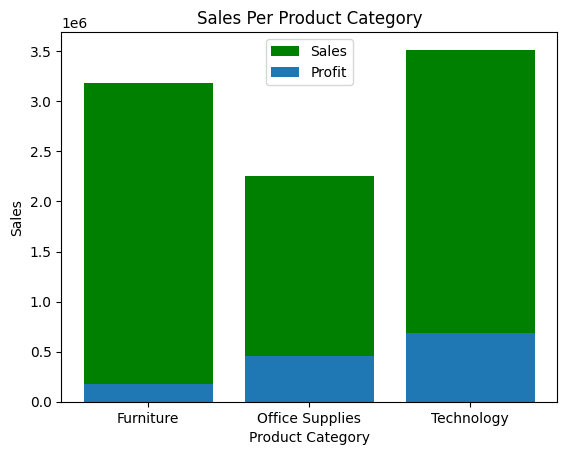

In [175]:
print(subCategory_sales)
#make bar diagram with two label sales and profit. make it appel to appel
plt.bar(subCategory_sales.index, subCategory_sales['Sales'],label='Sales', color = ('green'))
plt.bar(subCategory_sales.index, subCategory_sales['Profit'],label='Profit')
plt.title('Sales Per Product Category')
plt.xlabel('Product Category')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [208]:
#DataType Date Format
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'])
df.info()
#Filter 'East' Region
east_costumers = df[df['Region'] == 'East']
print(east_costumers.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9426 entries, 0 to 9425
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   City                  9426 non-null   object        
 1   Customer_ID           9426 non-null   int64         
 2   Customer_Name         9426 non-null   object        
 3   Customer_Segment      9426 non-null   object        
 4   Order_Date            9426 non-null   datetime64[ns]
 5   Order_ID              9426 non-null   int64         
 6   Order_Priority        9426 non-null   object        
 7   Postal_Code           9426 non-null   int64         
 8   Product_Category      9426 non-null   object        
 9   Product_Container     9426 non-null   object        
 10  Product_Name          9426 non-null   object        
 11  Product_Sub-Category  9426 non-null   object        
 12  Region                9426 non-null   object        
 13  Row_ID            

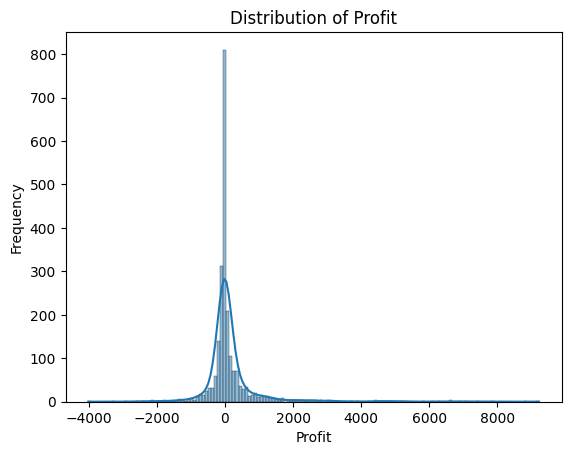

In [234]:
#Visualization with Seaborn
sns.histplot(data=east_costumers, x='Profit', bins=150, kde=True)
plt.title('Distribution of Profit')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.show()

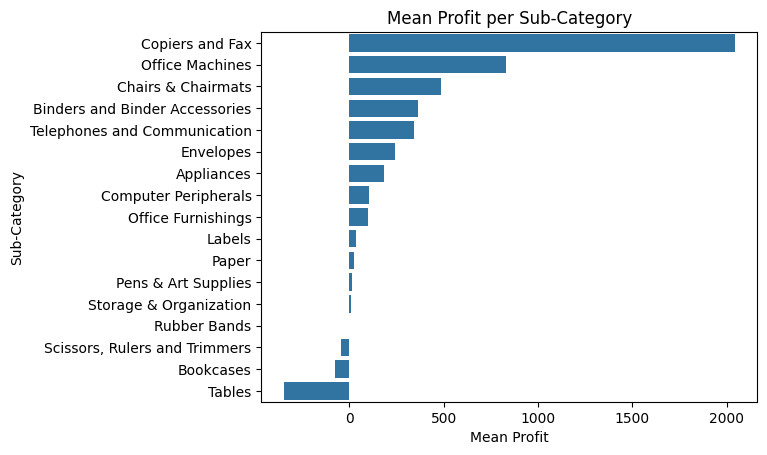

In [265]:
#Profit Mean per sub-Category and Visualisasi Bar
profit_mean = east_costumers.groupby('Product_Sub-Category')['Profit'].mean()
sns.barplot(x=profit_mean.values, y=profit_mean.index, order=profit_mean.sort_values(ascending=False).index)
plt.title('Mean Profit per Sub-Category')
plt.xlabel('Mean Profit')
plt.ylabel('Sub-Category')
plt.show()

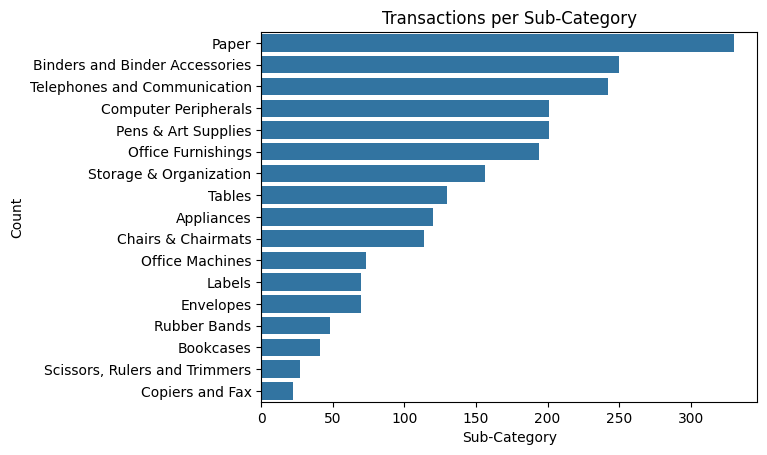

In [266]:
#Transactions per sub-category with Count Plot
sns.countplot(y='Product_Sub-Category', data=east_costumers, order=east_costumers['Product_Sub-Category'].value_counts().index)
plt.title('Transactions per Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Count')
plt.show()

<ipython-input-268-545eadf706e6>:2: UserWarning: 
The palette list has fewer values (2) than needed (17) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(


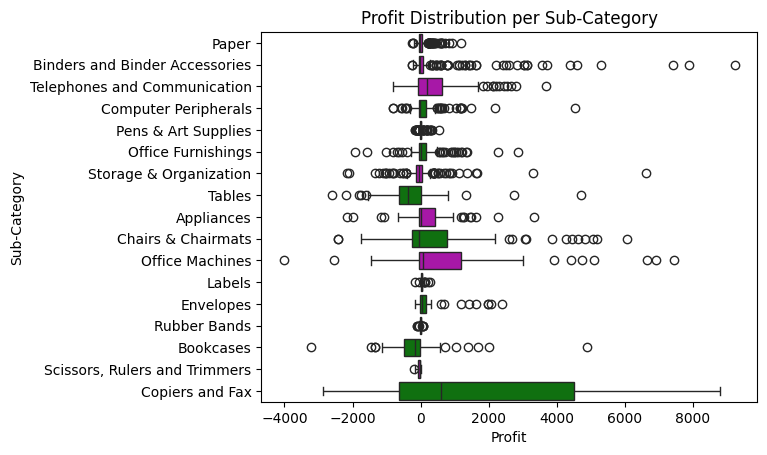

In [268]:
#Profit Disribution per sub-category with box plot
sns.boxplot(
    y='Product_Sub-Category',
    x='Profit', data=east_costumers,
    palette=["m", "g"],
    legend=False,
    hue='Product_Sub-Category',
    order=east_costumers['Product_Sub-Category'].value_counts().index)
plt.title('Profit Distribution per Sub-Category')
plt.xlabel('Profit')
plt.ylabel('Sub-Category')
plt.show()


In [300]:
df.info()
df.filter(['Customer_Segment','Discount'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9426 entries, 0 to 9425
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   City                  9426 non-null   object        
 1   Customer_ID           9426 non-null   int64         
 2   Customer_Name         9426 non-null   object        
 3   Customer_Segment      9426 non-null   object        
 4   Order_Date            9426 non-null   datetime64[ns]
 5   Order_ID              9426 non-null   int64         
 6   Order_Priority        9426 non-null   object        
 7   Postal_Code           9426 non-null   int64         
 8   Product_Category      9426 non-null   object        
 9   Product_Container     9426 non-null   object        
 10  Product_Name          9426 non-null   object        
 11  Product_Sub-Category  9426 non-null   object        
 12  Region                9426 non-null   object        
 13  Row_ID            

,Customer_Segment,Discount
0,Home Office,0.08
1,Corporate,0.00
2,Consumer,0.08
3,Corporate,0.07
4,Consumer,0.09
...,...,...
9421,Home Office,0.09
9422,Home Office,0.00
9423,Consumer,0.00
9424,Consumer,0.06


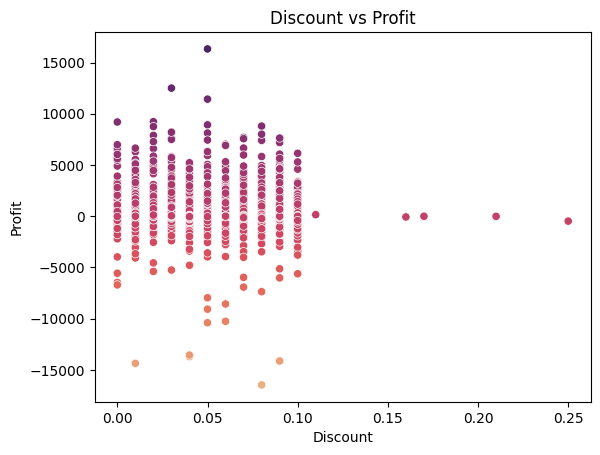

In [273]:
#Discount vs Profit with Scatter Plot
sns.scatterplot(x='Discount', y='Profit', data=df,palette='flare', hue='Profit', legend=False)
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()

Secara keseluruhan diskon vs keuntungan tidak terlihat saling mempengaruhi

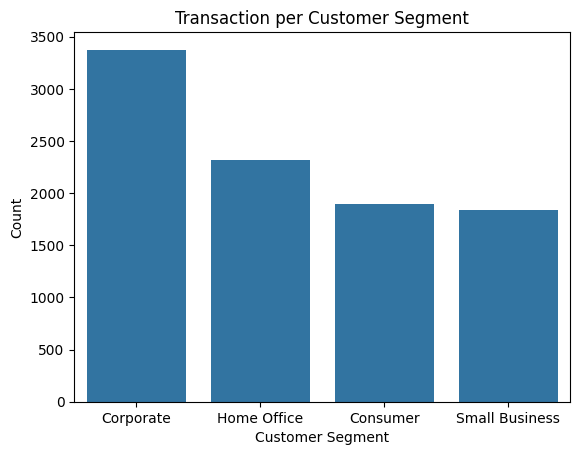

,count
Customer_Segment,
Corporate,3375
Home Office,2316
Consumer,1894
Small Business,1841


In [292]:
sns.barplot(x=df['Customer_Segment'].value_counts().index, y=df['Customer_Segment'].value_counts())
plt.title('Transaction per Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Count')
plt.show()
df['Customer_Segment'].value_counts()

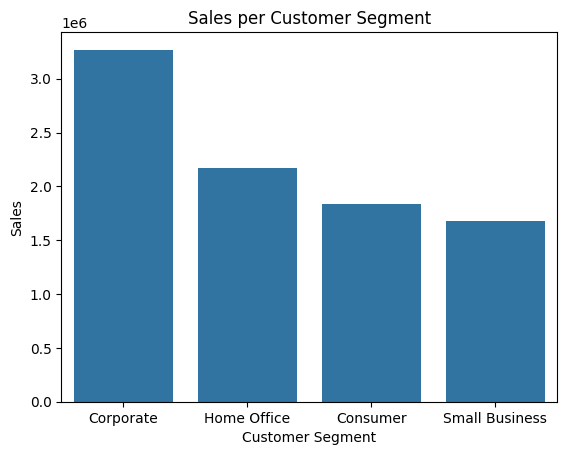

,Sales
Customer_Segment,
Corporate,3269391.07
Home Office,2168952.03
Consumer,1835215.22
Small Business,1678373.00


In [296]:
sum_sales_by_segment = df.groupby('Customer_Segment')['Sales'].sum()
sns.barplot(x=sum_sales_by_segment.index, y=sum_sales_by_segment, order=sum_sales_by_segment.sort_values(ascending=False).index)
plt.title('Sales per Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Sales')
plt.show()
sum_sales_by_segment.sort_values(ascending=False)

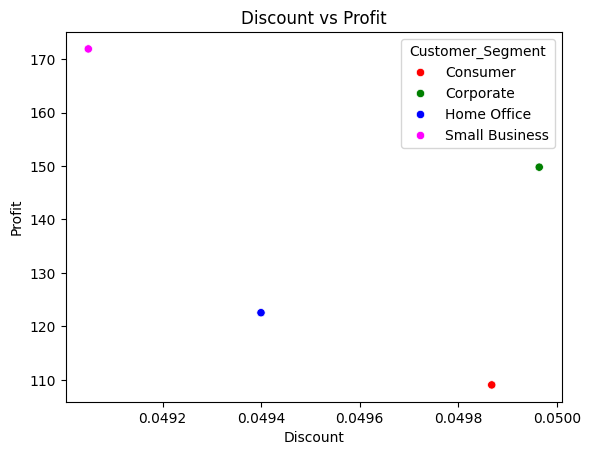

,Discount,Profit
Customer_Segment,,
Consumer,0.049868,109.059992
Corporate,0.049964,149.789223
Home Office,0.049400,122.568892
Small Business,0.049049,171.903635


In [302]:
costumers_segment = df.groupby('Customer_Segment')[['Discount','Profit']].mean()
sns.scatterplot(x=costumers_segment['Discount'],
                y=costumers_segment['Profit'],
                data=costumers_segment, palette=['red','green','blue','magenta'],
                hue=costumers_segment.index)
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()
costumers_segment

Segmentasi Kostumer 'Small Business' dengan rata-rata profit yang paling besar, sedangkan untuk Kostumer segmentasi 'Consumer' memiliki rata-rata profit yang sangat kecil Meskipun dengan rata diskon yang hampir sama. Total transaksi dan nilai penjualan 'Small Business' dan 'Consumer' hampir sama, jadi bisa dikatakan kalau diskon tidak berpengaruh terhadap profit